In [2]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

path=os.getenv("DATA_PATH")

df= pd.read_parquet(path+"/cleaned_Superstore.parquet",engine="fastparquet")


print(df.shape)
print("************************************************************************")
print(df.columns)
print("************************************************************************")
df.info()
print("************************************************************************")
df.describe()

(9994, 23)
************************************************************************
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month'],
      dtype='str')
************************************************************************
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Cus

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Month
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654


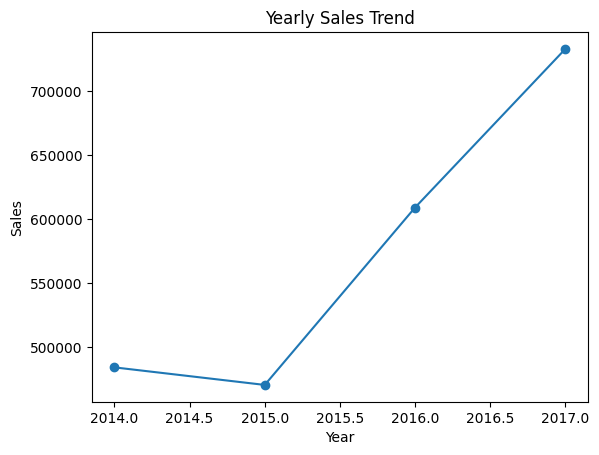

Year
2014         NaN
2015   -0.028322
2016    0.294715
2017    0.203560
Name: Sales, dtype: float64


In [3]:
import matplotlib.pyplot as plt

sales_trend = df.groupby('Year')['Sales'].sum()

sales_trend.plot(kind='line', marker='o')
plt.title("Yearly Sales Trend")
plt.ylabel("Sales")
plt.show()

growth = df.groupby('Year')['Sales'].sum().pct_change()
print(growth)

##Insights
- Sales experienced a slight decline from 2014 to 2015, followed by strong upward trend through 2017.
- The upward trend indicates a positive growth trajectory, which highlights opportunities to scale operations and invest further in high-performing segments.

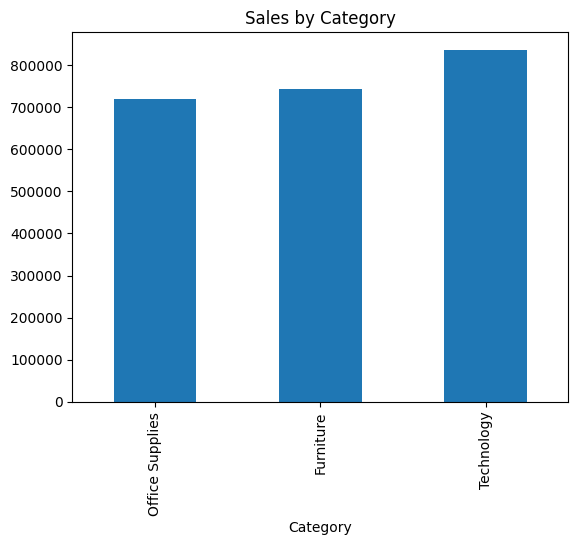

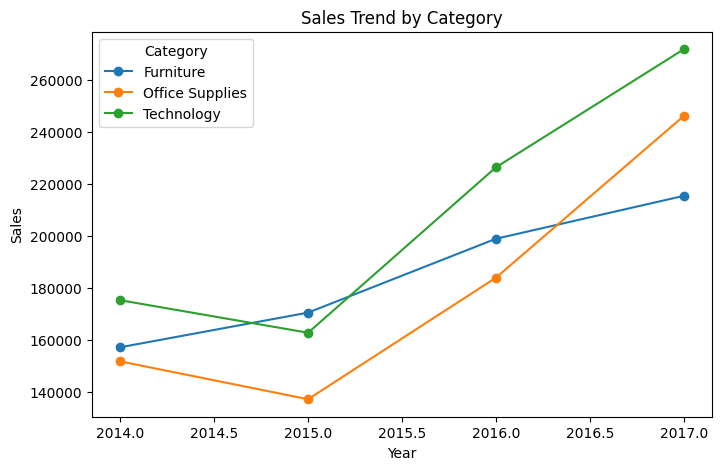

In [7]:
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar', title="Sales by Category")
category_trend = df.groupby(['Year', 'Category'])['Sales'].sum().unstack()

category_trend.plot(marker='o', figsize=(8,5))

import matplotlib.pyplot as plt
plt.title("Sales Trend by Category")
plt.ylabel("Sales")
plt.show()

##Insights
- Both Technology and Office supplies took a dip between 2014 and 2015, but showed growth through 2017.
- Technology has highest amount of sales among all three.
- While Furniture and Office supplies have relatively similar sales, Furniture outperforms Office supplies slightly.

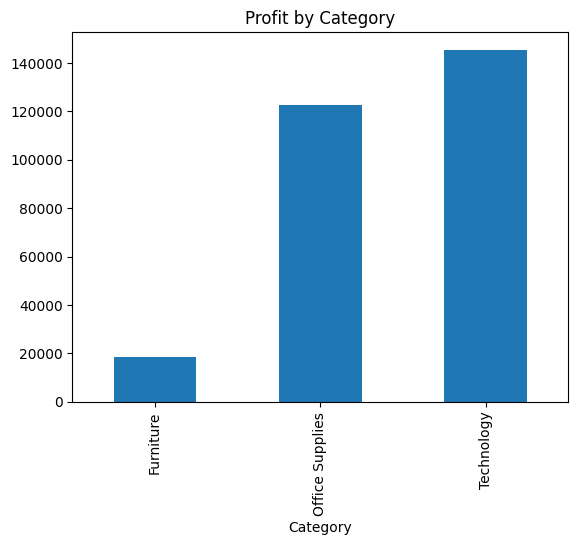

In [5]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

##Insights
- Technology shows the highest amount of profits.
- Office Supplies also generates substantial amount of sales, showing it's a reliability.
- Furniture shows the least amount of profit despite having comparable sales.
- The large gap between Furniture and other categories shows that there is room for improvement in the profitability through cost optimization, price management and other methods.

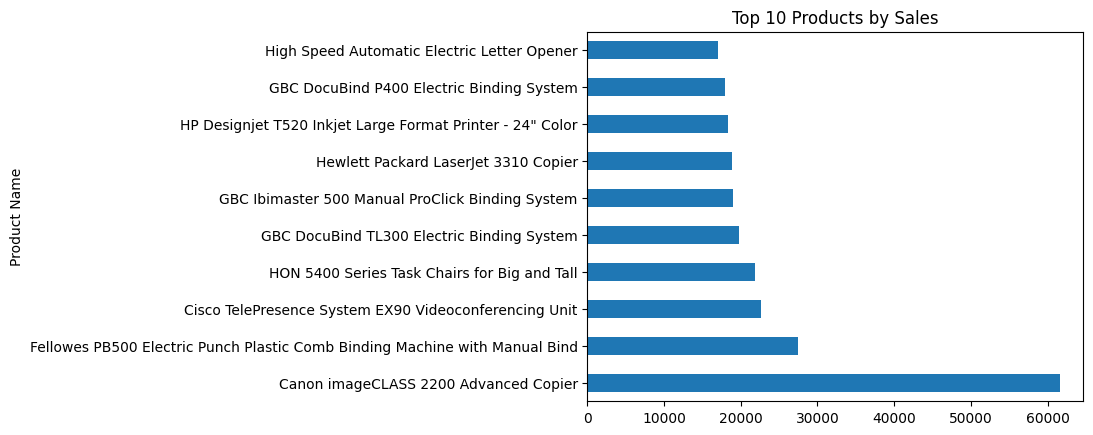

In [6]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.show()